# Exemplo 4 - Atividade em sala (Ajuste da distribuição normal)

Utilizando o método dos momentos, ajuste a distribuição normal à precipitação anual em College Station, Texas, de 1911 a 1979.
Plote as funções:
* a) função frequência relativa e função probabilidade incremental
* b) função frequência cumulativa e função probabilidade cumulativa

Use o teste de $\chi^2$ para determinar se a distribuição normal se ajusta adequadamente aos dados.

Os dados são fornecidos abaixo.

**Precipitação anual na College Station, Texas, 1911-1979 (pol)**

| Year | 1910 | 1920 | 1930 | 1940 | 1950 | 1960 | 1970 |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| 0 |     | 48.7 | 44.8 | 49.3 | 31.2 | 46.0 | 33.9 |
| 1 | 39.9 | 44.1 | 34.0 | 44.2 | 27.0 | 44.3 | 31.7 |
| 2 | 31.0 | 42.8 | 45.6 | 41.7 | 37.0 | 37.8 | 31.5 |
| 3 | 42.3 | 48.4 | 37.3 | 30.8 | 46.8 | 29.6 | 59.6 |
| 4 | 42.1 | 34.2 | 43.7 | 53.6 | 26.9 | 35.1 | 50.5 |
| 5 | 41.1 | 32.4 | 41.8 | 34.5 | 25.4 | 49.7 | 38.6 |
| 6 | 28.7 | 46.4 | 41.1 | 50.3 | 23.0 | 36.6 | 43.4 |
| 7 | 16.8 | 38.9 | 31.2 | 43.8 | 56.5 | 32.5 | 28.7 |
| 8 | 34.1 | 37.3 | 35.2 | 21.6 | 43.4 | 61.7 | 32.0 |
| 9 | 56.4 | 50.6 | 35.1 | 47.1 | 41.3 | 47.4 | 51.8 |

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

In [2]:
# Baixa dados da College Station, Texas
!gdown 122MCZkRoniGlkFXnLJLTvKJcLu-lbcZW

Downloading...
From: https://drive.google.com/uc?id=122MCZkRoniGlkFXnLJLTvKJcLu-lbcZW
To: /content/p_College_Station_Texas.csv
100% 700/700 [00:00<00:00, 2.50MB/s]


In [7]:
df  = pd.read_csv('p_College_Station_Texas.csv', index_col= 0, sep =',')
df.index=pd.to_datetime(df.index,format='%Y')
df

,p(in)
Year,
1911-01-01,39.9
1912-01-01,31.0
1913-01-01,42.3
1914-01-01,42.1
1915-01-01,41.1
...,...
1975-01-01,38.6
1976-01-01,43.4
1977-01-01,28.7


## Solução


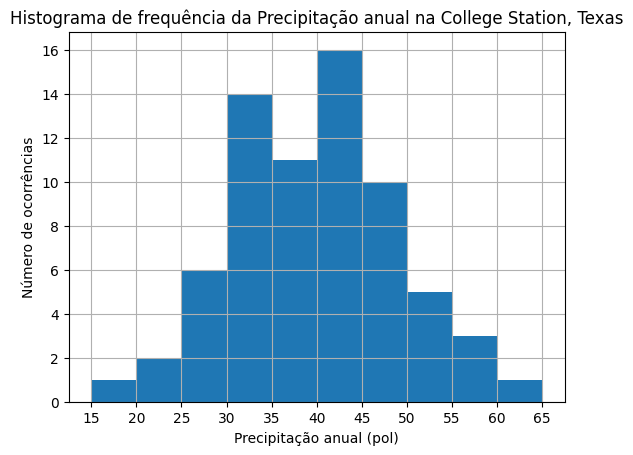

In [4]:
colunas = [15,20,25,30,35,40,45,50,55,60,65]
plt.xlabel('Precipitação anual (pol)')
plt.ylabel('Número de ocorrências')
plt.title('Histograma de frequência da Precipitação anual na College Station, Texas')
histograma = df['p(in)'].hist(bins=colunas)
plt.xticks(colunas)
plt.savefig('histograma_precipitação_anual.png', dpi = 300, bbox_inches='tight')
plt.show();

In [8]:
intervalos = ['<20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','>60']
superior = np.arange(20,70,5)
superior, len(superior), len(intervalos)

(array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65]), 10, 10)

In [25]:
contagem = np.zeros(len(intervalos))
contagem

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [26]:
df_contagem = pd.DataFrame({'Intervalo':intervalos, 'x':superior})
df_contagem

,Intervalo,x
0,<20,20
1,20-25,25
2,25-30,30
3,30-35,35
4,35-40,40
5,40-45,45
6,45-50,50
7,50-55,55
8,55-60,60
9,>60,65


In [27]:
# Mostra o valor que está na linha 0 da coluna 'p(in)' do dataframe df
df['p(in)'].iloc[0]

np.float64(39.9)

In [28]:
for i in range(len(df)):
  if df['p(in)'].iloc[i] < 20:
    contagem[0] += 1
  elif df['p(in)'].iloc[i] < 25:
    contagem[1] += 1
  elif df['p(in)'].iloc[i] < 30:
    contagem[2] += 1
  elif df['p(in)'].iloc[i] < 35:
    contagem[3] += 1
  elif df['p(in)'].iloc[i] < 40:
    contagem[4] += 1
  elif df['p(in)'].iloc[i] < 45:
    contagem[5] += 1
  elif df['p(in)'].iloc[i] < 50:
    contagem[6] += 1
  elif df['p(in)'].iloc[i] < 55:
    contagem[7] += 1
  elif df['p(in)'].iloc[i] < 60:
    contagem[8] += 1
  else:
    contagem[9] += 1

contagem

array([ 1.,  2.,  6., 14., 11., 16., 10.,  5.,  3.,  1.])

In [29]:
# outra forma de fazer a mesma coisa
contagem1 = []
for i in range(len(colunas)-1):
  #print(histograma.get_children()[i].get_height())
  contagem1.append(histograma.get_children()[i].get_height())
contagem1

[np.float64(1.0),
 np.float64(2.0),
 np.float64(6.0),
 np.float64(14.0),
 np.float64(11.0),
 np.float64(16.0),
 np.float64(10.0),
 np.float64(5.0),
 np.float64(3.0),
 np.float64(1.0)]

In [30]:
colunas

[15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65]

In [31]:
len(colunas), len(contagem)

(11, 10)

In [32]:
intervalos = ['<20','20-25','25-30','30-35','35-40','40-45','45-50','50-55','55-60','>60']
len(intervalos)

10

In [33]:
superior = np.arange(20,70,5)
superior, len(superior)

(array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65]), 10)

In [34]:
tabela = pd.DataFrame({'Intervalo':intervalos, 'x':superior, 'Contagem':contagem})
tabela

,Intervalo,x,Contagem
0,<20,20,1.0
1,20-25,25,2.0
2,25-30,30,6.0
3,30-35,35,14.0
4,35-40,40,11.0
5,40-45,45,16.0
6,45-50,50,10.0
7,50-55,55,5.0
8,55-60,60,3.0
9,>60,65,1.0


In [35]:
n = tabela['Contagem'].sum()
n

np.float64(69.0)

## Função frequência relativa $f_s(x)$

$$
f_s(x) = \frac{n_i}{n}
$$

In [36]:
tabela['fs'] = tabela['Contagem']/n
tabela

,Intervalo,x,Contagem,fs
0,<20,20,1.0,0.014493
1,20-25,25,2.0,0.028986
2,25-30,30,6.0,0.086957
3,30-35,35,14.0,0.202899
4,35-40,40,11.0,0.159420
5,40-45,45,16.0,0.231884
6,45-50,50,10.0,0.144928
7,50-55,55,5.0,0.072464
8,55-60,60,3.0,0.043478
9,>60,65,1.0,0.014493


## Função frequência cumulativa $F_s(x)$

$$
F_s\left(x_i\right)=\sum_{j=1}^i f_s\left(x_j\right)
$$


In [37]:
# duas formas de fazer a mesma coisa, uma mais longa:
Fs = []
soma = 0
for i in range(len(tabela)):
  soma += tabela['fs'][i]
  Fs.append(soma)
Fs

[np.float64(0.014492753623188406),
 np.float64(0.043478260869565216),
 np.float64(0.13043478260869565),
 np.float64(0.33333333333333337),
 np.float64(0.4927536231884058),
 np.float64(0.7246376811594203),
 np.float64(0.8695652173913043),
 np.float64(0.9420289855072463),
 np.float64(0.9855072463768115),
 np.float64(0.9999999999999999)]

In [38]:
# Uma mais curta:
Fs = tabela['fs'].cumsum()
Fs

,fs
0,0.014493
1,0.043478
2,0.130435
3,0.333333
4,0.492754
5,0.724638
6,0.869565
7,0.942029
8,0.985507
9,1.000000


In [39]:
tabela['Fs'] = Fs
tabela

,Intervalo,x,Contagem,fs,Fs
0,<20,20,1.0,0.014493,0.014493
1,20-25,25,2.0,0.028986,0.043478
2,25-30,30,6.0,0.086957,0.130435
3,30-35,35,14.0,0.202899,0.333333
4,35-40,40,11.0,0.159420,0.492754
5,40-45,45,16.0,0.231884,0.724638
6,45-50,50,10.0,0.144928,0.869565
7,50-55,55,5.0,0.072464,0.942029
8,55-60,60,3.0,0.043478,0.985507
9,>60,65,1.0,0.014493,1.000000


## Variável normal padrão

A variável normal padrão é $z$:
$$
z = \frac{x-\mu}{\sigma}
$$

sendo $\mu$ a média e $\sigma$ o desvio padrão

In [40]:
mu = df['p(in)'].mean()
sigma = df['p(in)'].std()

mu, sigma

(np.float64(39.76521739130435), 9.232166052751404)

In [41]:
z = (tabela['x'] - mu)/sigma
z

,x
0,-2.140908
1,-1.599323
2,-1.057738
3,-0.516154
4,0.025431
5,0.567016
6,1.108600
7,1.650185
8,2.191770
9,2.733354


In [42]:
tabela['z'] = z
tabela

,Intervalo,x,Contagem,fs,Fs,z
0,<20,20,1.0,0.014493,0.014493,-2.140908
1,20-25,25,2.0,0.028986,0.043478,-1.599323
2,25-30,30,6.0,0.086957,0.130435,-1.057738
3,30-35,35,14.0,0.202899,0.333333,-0.516154
4,35-40,40,11.0,0.159420,0.492754,0.025431
5,40-45,45,16.0,0.231884,0.724638,0.567016
6,45-50,50,10.0,0.144928,0.869565,1.108600
7,50-55,55,5.0,0.072464,0.942029,1.650185
8,55-60,60,3.0,0.043478,0.985507,2.191770
9,>60,65,1.0,0.014493,1.000000,2.733354


In [43]:
def B(z):
  """
  B is a polynomial approximation of the cumulative distribution function of the standard normal distribution.
  """
  return (1 / 2) * (1 + 0.196854 * abs(z) + 0.115194 * abs(z)**2 + 0.000344 * abs(z)**3 + 0.019527 * abs(z)**4)**(-4)

def normal_cdf(z):
  """
  Cumulative distribution function of the standard normal distribution.
  """
  if z < 0:
    return B(z)
  else:
    return 1 - B(z)

In [44]:
F = []
for i in range(len(tabela)):
  #print(tabela['z'][i], normal_cdf(tabela['z'][i]))
  F.append(normal_cdf(tabela['z'][i]))
F

[np.float64(0.016035560698625266),
 np.float64(0.05471771636127953),
 np.float64(0.14531994197631673),
 np.float64(0.30264401555646686),
 np.float64(0.5100336219809347),
 np.float64(0.714854147440954),
 np.float64(0.8659704050132697),
 np.float64(0.9507351391830721),
 np.float64(0.9858725029682999),
 np.float64(0.9966517046595346)]

In [45]:
tabela['F'] = F
tabela

,Intervalo,x,Contagem,fs,Fs,z,F
0,<20,20,1.0,0.014493,0.014493,-2.140908,0.016036
1,20-25,25,2.0,0.028986,0.043478,-1.599323,0.054718
2,25-30,30,6.0,0.086957,0.130435,-1.057738,0.145320
3,30-35,35,14.0,0.202899,0.333333,-0.516154,0.302644
4,35-40,40,11.0,0.159420,0.492754,0.025431,0.510034
5,40-45,45,16.0,0.231884,0.724638,0.567016,0.714854
6,45-50,50,10.0,0.144928,0.869565,1.108600,0.865970
7,50-55,55,5.0,0.072464,0.942029,1.650185,0.950735
8,55-60,60,3.0,0.043478,0.985507,2.191770,0.985873
9,>60,65,1.0,0.014493,1.000000,2.733354,0.996652


Função probabilidade incremental

In [46]:
p = []
p.append(tabela['F'][0])
for i in range(1,len(tabela)):
  p.append(tabela['F'][i] - tabela['F'][i-1])
p

[np.float64(0.016035560698625266),
 np.float64(0.03868215566265426),
 np.float64(0.0906022256150372),
 np.float64(0.15732407358015013),
 np.float64(0.20738960642446785),
 np.float64(0.20482052546001928),
 np.float64(0.15111625757231573),
 np.float64(0.08476473416980235),
 np.float64(0.035137363785227804),
 np.float64(0.010779201691234697)]

In [47]:
tabela['p(x)'] = p
tabela

,Intervalo,x,Contagem,fs,Fs,z,F,p(x)
0,<20,20,1.0,0.014493,0.014493,-2.140908,0.016036,0.016036
1,20-25,25,2.0,0.028986,0.043478,-1.599323,0.054718,0.038682
2,25-30,30,6.0,0.086957,0.130435,-1.057738,0.145320,0.090602
3,30-35,35,14.0,0.202899,0.333333,-0.516154,0.302644,0.157324
4,35-40,40,11.0,0.159420,0.492754,0.025431,0.510034,0.207390
5,40-45,45,16.0,0.231884,0.724638,0.567016,0.714854,0.204821
6,45-50,50,10.0,0.144928,0.869565,1.108600,0.865970,0.151116
7,50-55,55,5.0,0.072464,0.942029,1.650185,0.950735,0.084765
8,55-60,60,3.0,0.043478,0.985507,2.191770,0.985873,0.035137
9,>60,65,1.0,0.014493,1.000000,2.733354,0.996652,0.010779


### Teste de $\chi^2$

$$
\chi_{c}^{2}=\sum_{i=1}^{m} \frac{n [ f_{s} ( x_{i} )-p ( x_{i} ) ]^{2}} {p ( x_{i} )}
$$

In [48]:
tabela['chi2'] = (n * (tabela['fs'] - tabela['p(x)'])**2)/tabela['p(x)']
tabela

,Intervalo,x,Contagem,fs,Fs,z,F,p(x),chi2
0,<20,20,1.0,0.014493,0.014493,-2.140908,0.016036,0.016036,0.010242
1,20-25,25,2.0,0.028986,0.043478,-1.599323,0.054718,0.038682,0.167719
2,25-30,30,6.0,0.086957,0.130435,-1.057738,0.145320,0.090602,0.010122
3,30-35,35,14.0,0.202899,0.333333,-0.516154,0.302644,0.157324,0.910956
4,35-40,40,11.0,0.159420,0.492754,0.025431,0.510034,0.207390,0.765578
5,40-45,45,16.0,0.231884,0.724638,0.567016,0.714854,0.204821,0.246743
6,45-50,50,10.0,0.144928,0.869565,1.108600,0.865970,0.151116,0.017488
7,50-55,55,5.0,0.072464,0.942029,1.650185,0.950735,0.084765,0.123172
8,55-60,60,3.0,0.043478,0.985507,2.191770,0.985873,0.035137,0.136617
9,>60,65,1.0,0.014493,1.000000,2.733354,0.996652,0.010779,0.088276


In [49]:
print(tabela['p(x)'].sum(), tabela['chi2'].sum())
soma_chi2 = tabela['chi2'].sum()

0.9966517046595346 2.476912233334598


In [50]:
print(f"Soma de p(x): {tabela['p(x)'].sum():.2f}")
print(f"Soma de chi2: {tabela['chi2'].sum():.2f}")


Soma de p(x): 1.00
Soma de chi2: 2.48


In [52]:
# graus de liberdade
m = len(tabela)
print(m)
p = 2
v = m - p - 1
print(v)

10
7


In [53]:
soma_chi2

np.float64(2.476912233334598)

Temos que  $\chi^2_c = 2.48$

Como encontrar $\chi^2_{\nu,1-\alpha}$?

Para encontrar o valor crítico da distribuição $\chi^2$: $\chi^2_{\nu,1-\alpha}$ vamos usar:

https://docs.scipy.org/doc/scipy-1.12.0/reference/generated/scipy.stats.chi2.html



Temos que:

* $\nu = 7$
* $\alpha = 0.05$
* $1 - \alpha = 0.95$

A função `scipy.stats.chi2.isf` nos fornece o valor de $\chi^2_{7,1-0.05}$

In [56]:
import scipy

In [58]:
scipy.stats.chi2?

In [60]:
chi_critico = scipy.stats.chi2.isf(0.05, 7, loc=0, scale=1) # p=5%, df=7 (p = nível de significância, df = graus de liberdade)
chi_critico

np.float64(14.067140449340167)

In [61]:
soma_chi2 < chi_critico

np.True_

Como $\chi^2_c < \chi^2_{\nu,1-\alpha}$ $\rightarrow$ a hipótese nula não pode ser rejeitada no nível de confiança de 95\%. Ou seja, o ajuste da distribuição normal aos dados de precipitação anual de College Station é aceito.

In [63]:
tabela['centro'] = tabela['x'] - 2.5
tabela

,Intervalo,x,Contagem,fs,Fs,z,F,p(x),chi2,centro
0,<20,20,1.0,0.014493,0.014493,-2.140908,0.016036,0.016036,0.010242,17.5
1,20-25,25,2.0,0.028986,0.043478,-1.599323,0.054718,0.038682,0.167719,22.5
2,25-30,30,6.0,0.086957,0.130435,-1.057738,0.145320,0.090602,0.010122,27.5
3,30-35,35,14.0,0.202899,0.333333,-0.516154,0.302644,0.157324,0.910956,32.5
4,35-40,40,11.0,0.159420,0.492754,0.025431,0.510034,0.207390,0.765578,37.5
5,40-45,45,16.0,0.231884,0.724638,0.567016,0.714854,0.204821,0.246743,42.5
6,45-50,50,10.0,0.144928,0.869565,1.108600,0.865970,0.151116,0.017488,47.5
7,50-55,55,5.0,0.072464,0.942029,1.650185,0.950735,0.084765,0.123172,52.5
8,55-60,60,3.0,0.043478,0.985507,2.191770,0.985873,0.035137,0.136617,57.5
9,>60,65,1.0,0.014493,1.000000,2.733354,0.996652,0.010779,0.088276,62.5


In [64]:
tabela['fs'].values

array([0.01449275, 0.02898551, 0.08695652, 0.20289855, 0.15942029,
       0.23188406, 0.14492754, 0.07246377, 0.04347826, 0.01449275])

In [65]:
tabela['centro'].values

array([17.5, 22.5, 27.5, 32.5, 37.5, 42.5, 47.5, 52.5, 57.5, 62.5])

Gráficos:

Vamos comparar a **função frequência relativa** $f_s(x)$ com a **função densidade de probabilidade** $f(x)$ ou melhor, a **função de probabilidade incremental** $p(x)$ para cada valor médio do histograma:

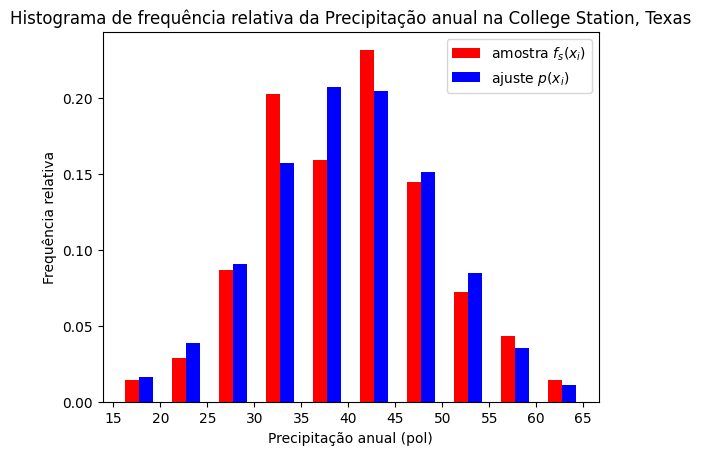

In [72]:
colunas = [15,20,25,30,35,40,45,50,55,60,65]
plt.xlabel('Precipitação anual (pol)')
plt.ylabel('Frequência relativa')
plt.title('Histograma de frequência relativa da Precipitação anual na College Station, Texas')
# bar plots
plt.bar(tabela['centro'].values-0.5,tabela['fs'].values, color ='red', width = 1.5,label=r'amostra $f_s(x_i)$')
plt.bar(tabela['centro'].values+1.0,tabela['p(x)'].values, color ='blue', width = 1.5,label=r'ajuste $p(x_i)$')
plt.xticks(colunas)
plt.legend()
plt.savefig('histograma_freq_rel.png', dpi = 300, bbox_inches='tight')
plt.show();

Agora vamos plotar a **função frequência cumulativa** $F_s(x)$ $\times$ a **função distribuição de probabilidade** $F(x)$ ajustada pelo método dos momentos:

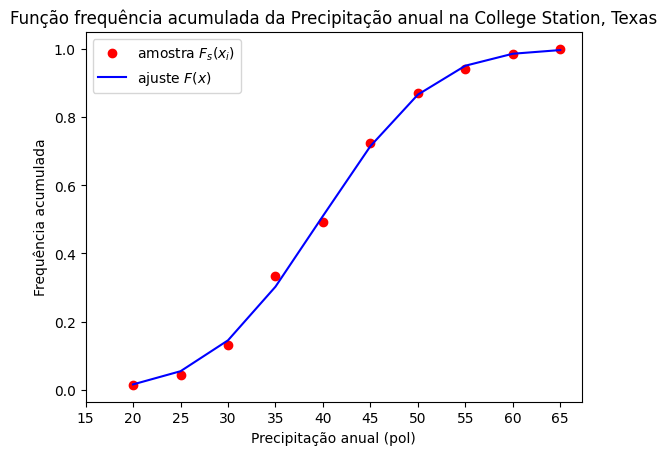

In [71]:
plt.xlabel('Precipitação anual (pol)')
plt.ylabel('Frequência acumulada')
plt.title('Função frequência acumulada da Precipitação anual na College Station, Texas')
# bar plots
plt.plot(tabela['x'].values,tabela['Fs'].values, 'o', color ='red', label=r'amostra $F_s(x_i)$')
plt.plot(tabela['x'].values,tabela['F'].values, color ='blue', label=r'ajuste $F(x)$')
plt.xticks(colunas)
plt.legend()
plt.savefig('histograma_acumulado.png', dpi = 300, bbox_inches='tight')
plt.show();

O ajuste da distribuição normal aos dados de precipitação anual de College Station é aceito.

In [69]:
print(f"Média e Desvio Padrão: {mu:.2f} e {sigma:.2f}")

Média e Desvio Padrão: 39.77 e 9.23


In [ ]:
|